# **Package Installations and Calls**

In [ ]:
# Import DS Python Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Modeling libraries
import xgboost as xgb
from sklearn import metrics
from sklearn.model_selection import train_test_split, PredefinedSplit
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Extra tools
from tqdm import trange
from time import time
import pickle

# **Read in Data**

In [ ]:
train_df = pd.read_csv("./data/train_67.csv",
                       dtype = {"siteid" : "category", "sex" : "category",
                               "race" : "category", "historysmoking": "category"})
test_df = pd.read_csv("./data/test_33.csv",
                      dtype = {"siteid" : "category", "sex" : "category",
                               "race" : "category", "historysmoking": "category"})

In [ ]:
y_train = train_df["dropout"]
X_train = train_df.drop("dropout", axis = 1)
X_holdout = test_df.drop("dropout", axis = 1)
y_holdout = test_df["dropout"]
X_train.shape, y_train.shape

((191, 37), (191,))

# **Set Up Data**

In [ ]:
X = pd.concat([X_train, X_holdout])
y = pd.concat([y_train, y_holdout])

X['siteid'] = X['siteid'].astype('category')

X.shape, y.shape

((281, 37), (281,))

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 281 entries, 0 to 89
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype   
---  ------                                          --------------  -----   
 0   randomized_study_binary                         281 non-null    int64   
 1   treatment_group                                 281 non-null    int64   
 2   age                                             281 non-null    int64   
 3   sex                                             281 non-null    category
 4   siteid                                          281 non-null    category
 5   race                                            281 non-null    category
 6   ethnicity                                       281 non-null    int64   
 7   diabetes                                        281 non-null    int64   
 8   atrialfibflutter                                281 non-null    int64   
 9   CABG                                  

# **XGBoost Model**

In [ ]:
start = time()

scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

split_index = np.zeros(len(y), dtype = int)
ps = PredefinedSplit(test_fold = split_index)

xgb_model = xgb.XGBClassifier(random_state = 22,
                              scale_pos_weight = scale_pos_weight,
                              learning_rate = 0.05,
                              early_stopping_rounds = 15,
                              device = "cuda",
                              tree_method = "gpu_hist",
                              eval_metric = "auc",
                              enable_categorical = True,
                              verbosity = 0)

param_grid = {
    'n_estimators': [100, 300, 500, 700, 900, 1100], # Number of boosting trees
    'colsample_bytree': [0.5, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85],
    'max_depth': [5, 7, 9, 11, 13],               # Maximum depth of each tree
    'subsample': [0.4, 0.5, 0.6, 0.7, 0.8],    # Proportion of samples to train each tree
    'min_child_weight': [1, 3, 5]            # Minimum sum of instance weight for a child
}

# Grid search
grid_model = GridSearchCV(estimator = xgb_model, param_grid = param_grid,
                     cv = ps, n_jobs = -1, verbose = 2, scoring = 'f1')

grid_model.fit(X, y,
               eval_set = [(X, y)],
               verbose = False)

end = time()
print("Took", round(((end- start) / 60), 4), "minutes to search for the best model.")

Fitting 1 folds for each of 3150 candidates, totalling 3150 fits


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(


Took 3.4008 minutes to search for the best model.


In [ ]:
grid_model.best_params_

{'colsample_bytree': 0.5,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 100,
 'subsample': 0.4}

## Fit the Best Model

In [ ]:
params = grid_model.best_params_

scale_pos_weight = np.sum(y == 0) / np.sum(y == 1)

best_xgb_model = xgb.XGBClassifier(**params,
                                   random_state = 22,
                                   scale_pos_weight = scale_pos_weight,
                                   learning_rate = 0.05,
                                   early_stopping_rounds = 15,
                                   device = "cuda",
                                   tree_method = "gpu_hist",
                                   eval_metric = "auc",
                                   enable_categorical = True,
                                   verbosity = 0).fit(X, y,
                                                      eval_set = [(X, y)],
                                                      verbose = False)

In [ ]:
# Saving data by pickling data into pkl files to avoid running code for data again
# modeling = {
#     "cv_results": grid_model,
#     "best_model": best_xgb_model
# }
with open('explanatory_dropout_cv.pkl', 'wb') as file:
    pickle.dump(grid_model, file)
with open('explanatory_dropout_model.pkl', 'wb') as file:
    pickle.dump(best_xgb_model, file)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [07:21:11] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


# **Results**

## Get Predictions

In [ ]:
# Read the pickled model and CV results
with open('explanatory_dropout_cv.pkl', 'rb') as file:
    grid_model = pickle.load(file)

with open('explanatory_dropout_model.pkl', 'rb') as file:
    xgb_model = pickle.load(file)

In [ ]:
# Predicted labels and probabilities
y_pred_xgb = xgb_model.predict(X)
prob_pred_xgb = xgb_model.predict_proba(X)

In [ ]:
# Probability Distribution
pd.DataFrame(prob_pred_xgb).describe()

,0,1
count,281.000000,281.000000
mean,0.588862,0.411138
std,0.243726,0.243726
min,0.112266,0.068658
25%,0.321857,0.200572
50%,0.689728,0.310272
75%,0.799428,0.678143
max,0.931342,0.887734


Text(0.5, 1.0, 'Distribution of Predicted Probs by True Label in the Dropout Model')

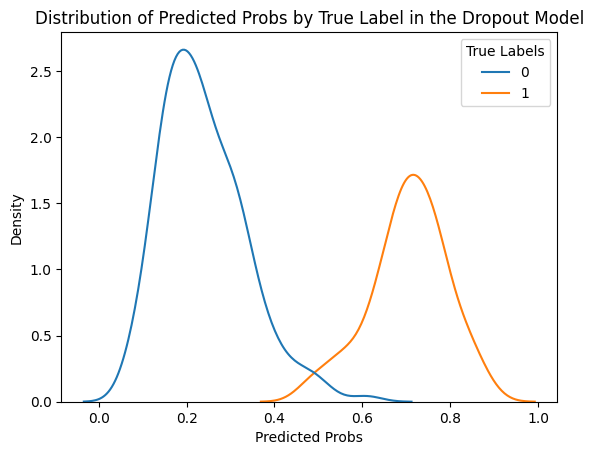

In [ ]:
tmp = pd.concat([pd.DataFrame(pos_probs), y.reset_index(drop = True)],
                axis = 1)
tmp.columns = ["Predicted Probs", "True Labels"]
sns.kdeplot(data = tmp, x = "Predicted Probs", hue = "True Labels")#, kde = True)
plt.title("Distribution of Predicted Probs by True Label in the Dropout Model")

In [ ]:
# Get evaluation results
results = xgb_model.evals_result()

# Extract train and validation loss
train_loss = results['validation_0']['auc']

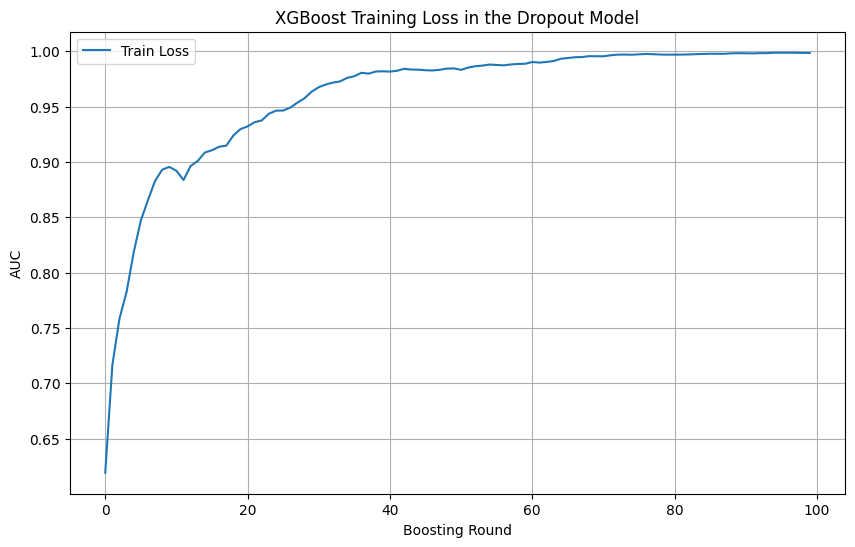

In [ ]:
# Plot loss as a function of training rounds
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label = 'Train Loss')
plt.xlabel('Boosting Round')
plt.ylabel('AUC')
plt.title('XGBoost Training Loss in the Dropout Model')
plt.legend()
plt.grid(True)
plt.show()

## Get Classification Metrics

In [ ]:
def evaluate_metrics(y_vec, y_hat, prob_hat, model_name = "model"):
    # Confusion Matrix
    confMat = metrics.confusion_matrix(y_vec, y_hat)
    tn, fp, fn, tp = confMat.ravel()

    # Metrics
    accuracy = metrics.accuracy_score(y_vec, y_hat)
    sensitivity = metrics.recall_score(y_vec, y_hat)  # Same as recall (TPR)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 # No inf division
    precision = metrics.precision_score(y_vec, y_hat)
    recall = sensitivity
    f1 = metrics.f1_score(y_vec, y_hat)
    brier = metrics.brier_score_loss(y_vec, prob_hat)
    auc = metrics.roc_auc_score(y_vec, prob_hat)

    # Store all metrics in a dictionary
    all_metrics = {
        "accuracy": accuracy,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "brier": brier,
        "auc": auc
    }

    # dataframe to column bind to others for viewing
    return pd.DataFrame(all_metrics, index=[model_name]).T

In [ ]:
# Get all composite classification metrics
xgb_train_metrics = evaluate_metrics(y, y_pred_xgb,
                                    pos_probs, # probabilities of being in class 1
                                    model_name = "XGB Train")

In [ ]:
xgb_train_metrics

,XGB Train
accuracy,0.982206
sensitivity,0.971154
specificity,0.988701
precision,0.980583
recall,0.971154
f1,0.975845
tp,101.000000
fp,2.000000
tn,175.000000
fn,3.000000


## Feature Importance

<Axes: title={'center': 'XGBoost Dropout Model Feature Importance'}, xlabel='F score', ylabel='Features'>

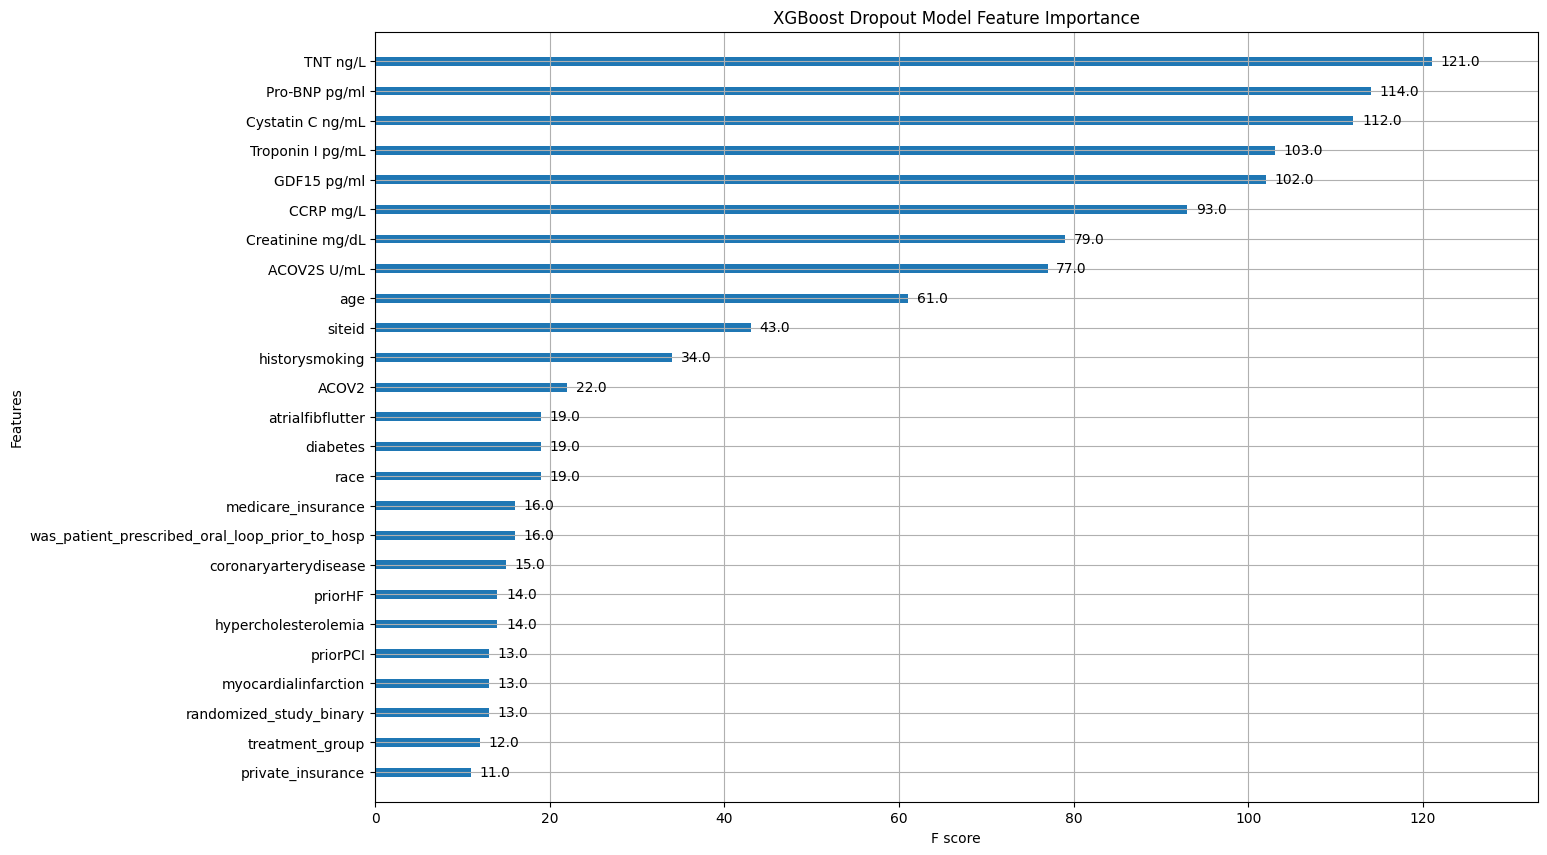

In [ ]:
xgb_model.get_booster().feature_names = X.columns.to_list()

xgb.plot_importance(xgb_model, max_num_features = 25, title = "XGBoost Dropout Model Feature Importance",
                    height = 0.3)

**Note**: This feature importance plot uses XGBoost’s default weight (F score), which counts how often each feature is used as a split across all trees. As a result, features that can be split in many ways (for example, continuous or high‑cardinality variables) may appear more important than low‑cardinality or binary features.